In [57]:
#Python v3.11.8
#Import necessary packages

import os
import sys

import pandas as pd
import numpy as np

sys.path.append('functions')

from greatbrowser import great_analysis

from gene_analysis_functions import get_cistrome, get_pos, insig_nan
from pseudoinverse_functions import pinv_dropmin, quality_filter, trait_cluster

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
'''
Establich cwd, get relevant data, and perform basic formatting
'''

#set directory, import data, drop undefined
os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/raw_data')
data = pd.read_excel('methylation_phenotype_encoded.xlsx', index_col=0) #mm39
data = data.dropna()

#referring to the point in the data where methylation and phenotype data diverge
sep=55

#seperate trait and methylation data
trait_data = data[:sep]
meth_data = data[sep:]

print(f'{trait_data.shape[0]} traits')

55 traits


In [59]:
#filter trait data to minimize colinearity
filter = 0.5
f_trait_data = quality_filter(trait_data, filter)

print(f'\n{f_trait_data.shape[0]} traits')

initializing: M12_poststress_GLU
M10_poststress_GLU corr: 0.6719015152375838
M8_poststress_GLU corr: 0.6090336912254721
removing: M8_poststress_GLU
M6_poststress_GLU corr: 0.5802400592602832
removing: M6_poststress_GLU
M4_poststress_GLU corr: 0.5311748134680883
removing: M4_poststress_GLU
M2_poststress_GLU corr: 0.3228813190001512
w4_stress_GLU corr: 0.3560799023117119
Baseline_GLU corr: 0.4321213022396831
M12_poststress_FFM_g corr: 0.016038987694264484
M10_poststress_FFM_g corr: 0.1032664053853798
M8_poststress_FFM_g corr: 0.13022424239458588
M6_poststress_FFM_g corr: 0.14497224377218185
M4_poststress_FFM_g corr: 0.13864898633105477
M2_poststress_FFM_g corr: 0.040837730206165726
w4_stress_FFM_g corr: 0.010086677800758868
Baseline_FFM_g corr: 0.04630001033314697
M12_poststress_FM_g corr: 0.15170584503159446
M10_poststress_FM_g corr: 0.3359654636524691
M8_poststress_FM_g corr: 0.30474076619102525
M6_poststress_FM_g corr: 0.5008174335569449
removing: M6_poststress_FM_g
M4_poststress_FM_g

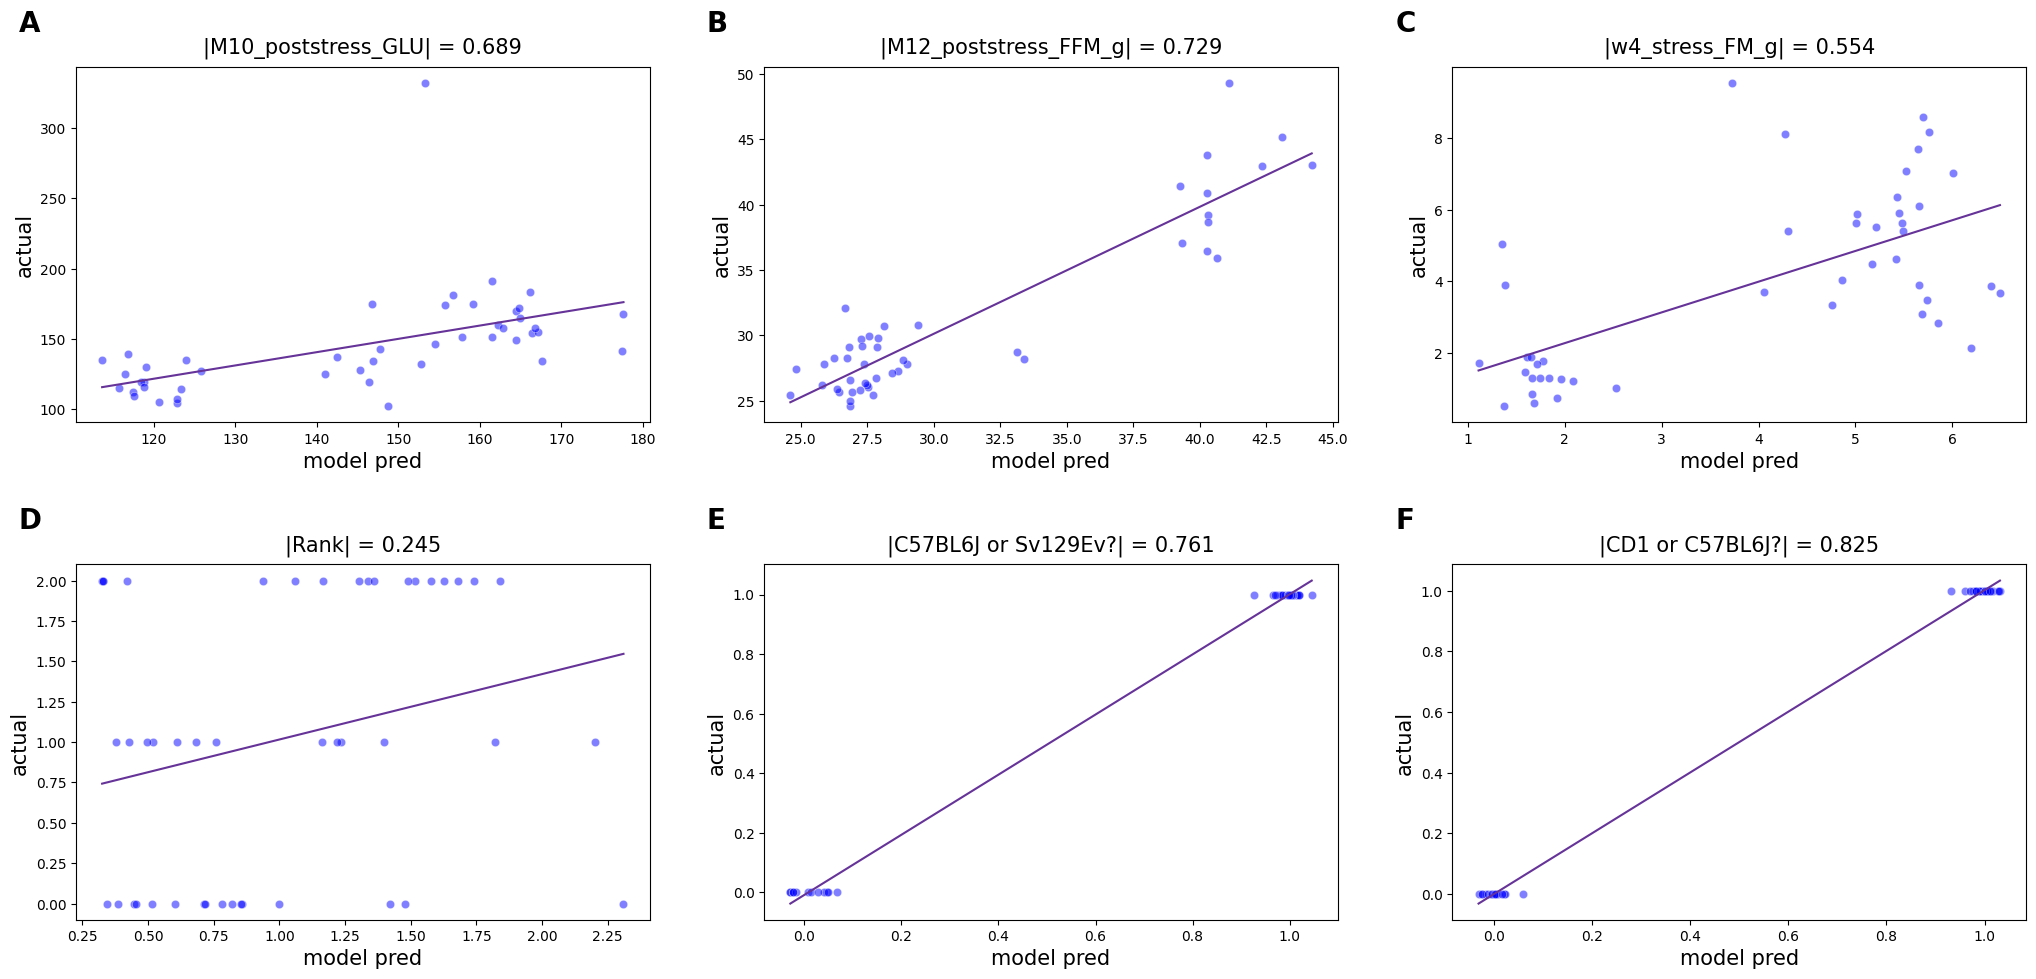

In [60]:
#generate pseudoinversion plots
thresh = 0.5
meth_filter_thresh = 0.5
pinv_dropmin(f_trait_data, meth_data, thresh, 
             find_meth=False, to_filter_meth=True, 
             meth_filter_thresh=meth_filter_thresh);

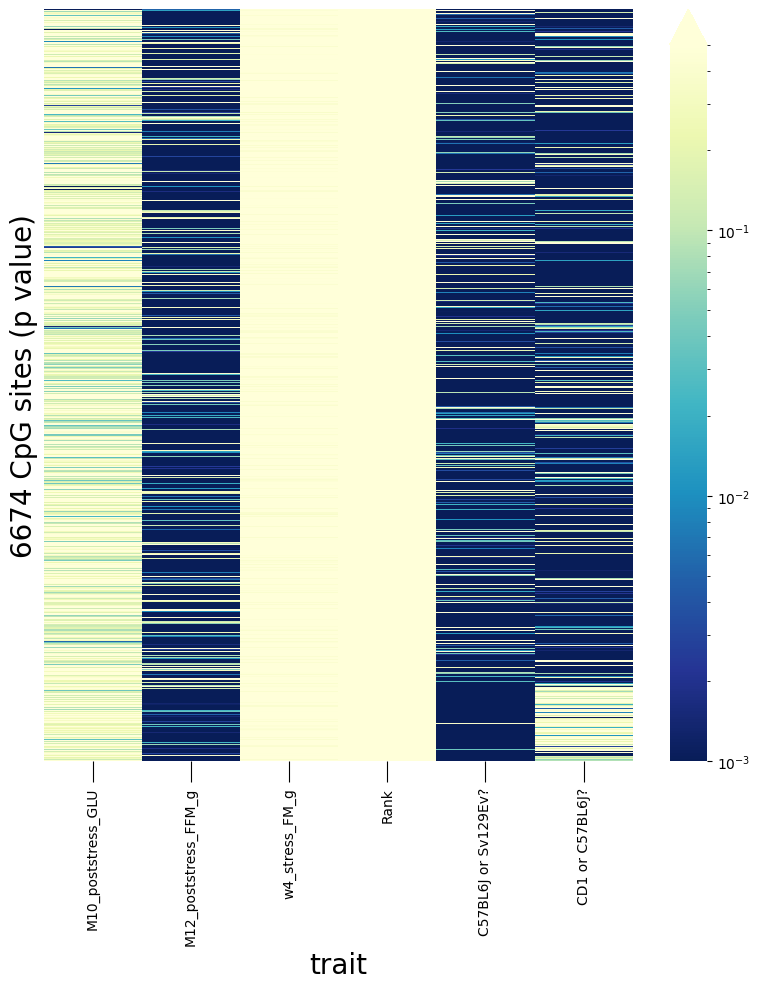

In [61]:
#generate heatmap of probe/trait multivar association p values
thresh = 0.5
meth_filter_thresh = 0.5
is_filtered = True
trait_vals, trait_pvals, trait_coef = pinv_dropmin(f_trait_data, meth_data, thresh, 
                                                   find_meth=True, plot_results=True, 
                                                   to_filter_meth=is_filtered, meth_filter_thresh=meth_filter_thresh);

In [62]:
#identify most significant probes
mm39_data = pd.read_excel('mm39_formatted_manifest.xlsx', index_col=0)
probe_df = get_pos(trait_vals, mm39_data);

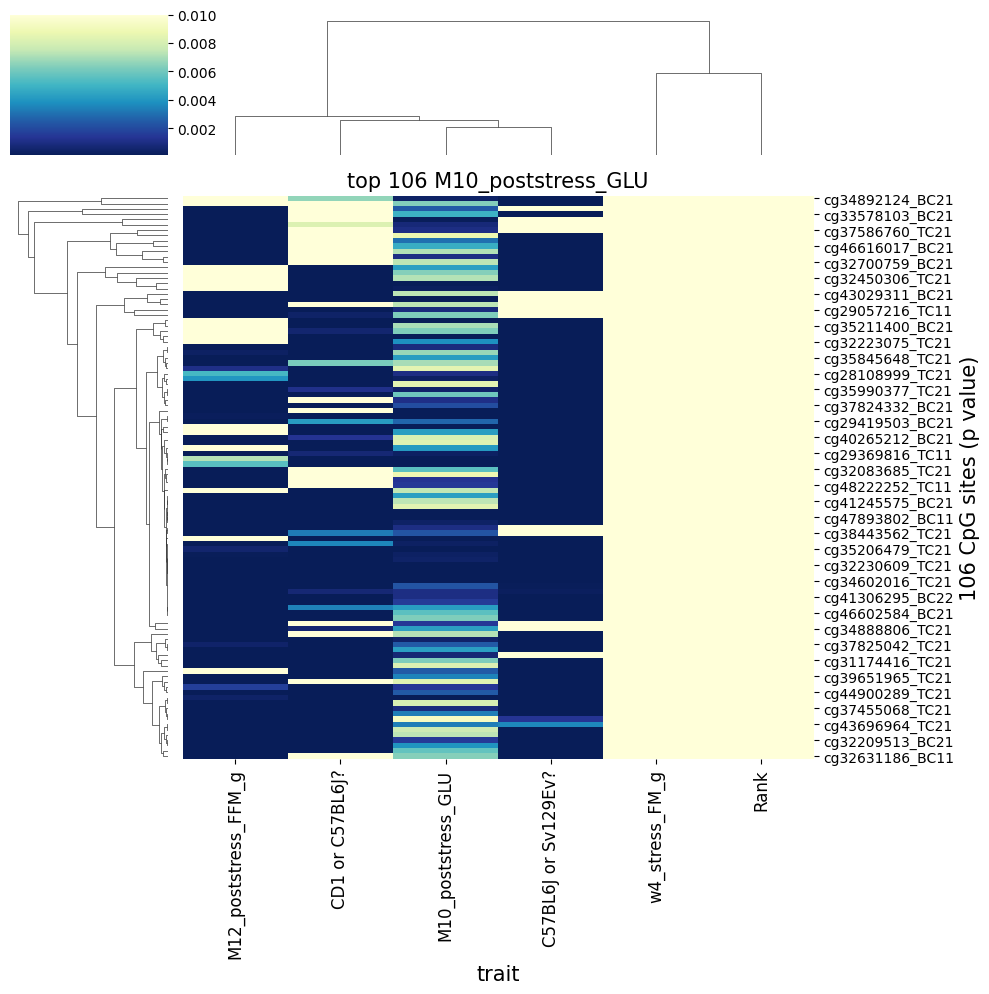

In [63]:
#generate a clustermap of significant probes for selected trait
sig_df = insig_nan(probe_df)
trait = 'M10_poststress_GLU_pval'

temp = sig_df[trait].values
temp = temp[~np.isnan(temp)]
n_probes = len(temp)

trait_cluster(trait_pvals, trait[:-5], n_probes);

In [64]:
#find gene associations of probes via GREAT

temp = probe_df.reset_index()
temp = great_analysis(temp, get='genes', df_chr ='chr_mm10', df_start='pos_mm10', df_end='end_mm10', df_index='index')

temp = temp.set_index('index')
trait_vals['associated_genes'] = temp['associated_genes']

if is_filtered:
    trait_vals.to_excel('pseudoinverse_probes_filtered.xlsx')
else:
    trait_vals.to_excel('pseudoinverse_probes_unfiltered.xlsx')

trait_vals

,M10_poststress_GLU_pval,M10_poststress_GLU_coef,M12_poststress_FFM_g_pval,M12_poststress_FFM_g_coef,w4_stress_FM_g_pval,w4_stress_FM_g_coef,Rank_pval,Rank_coef,C57BL6J or Sv129Ev?_pval,C57BL6J or Sv129Ev?_coef,CD1 or C57BL6J?_pval,CD1 or C57BL6J?_coef,chr_mm39,pos_mm39,end_mm39,chr_mm10,pos_mm10,end_mm10,associated_genes
index,,,,,,,,,,,,,,,,,,,
cg20012035_TC21,0.151314,-0.000376,9.311522e-09,0.006174,0.620796,0.003210,0.999737,0.001522,1.293483e-21,0.240577,1.309656e-10,0.172601,chr12,111505954,111505956,chr12,111539520.0,111539522.0,"Mark3 (-35,006), Eif5 (+1,505)"
cg28108944_BC11,0.125165,-0.000326,9.637133e-17,0.010206,0.447444,0.004188,0.999737,0.005131,2.422252e-23,0.213921,1.548287e-11,0.148717,chr12,20109465,20109467,chr12,20059464.0,20059466.0,"Gm10479 (-356,473)"
cg28108956_TC21,0.112542,-0.000382,2.576322e-14,0.008952,0.405204,0.005866,0.999737,-0.002823,1.169303e-22,0.227587,1.466028e-12,0.180622,chr6,40524504,40524506,chr6,40547570.0,40547572.0,"Prss37 (-28,063), Olfr461 (+7,479)"
cg28108957_BC21,0.101060,-0.000384,9.199670e-16,0.009820,0.493592,0.003841,0.999737,-0.002778,3.884515e-22,0.211901,1.842929e-11,0.158505,chr17,49754778,49754780,chr17,49447750.0,49447752.0,"Mocs1 (+19,341), Daam2 (+116,592)"
cg28108999_TC21,0.001028,-0.000746,5.138223e-03,0.002040,0.484337,0.003768,0.999737,0.002749,4.603250e-11,0.089536,2.091271e-12,0.163352,chr10,3207379,3207381,chr10,3257379.0,3257381.0,"H60c (+10,391)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg48343432_BC11,0.578752,0.000624,5.268797e-01,-0.002284,0.640941,0.012552,0.999737,0.008998,2.961393e-03,0.161420,5.465837e-09,0.607601,chrY,90751530,90751532,chrY,90740261.0,90740263.0,"Gm21996 (-994,730), Erdr1 (-44,476)"
cg48343860_TC21,0.333483,0.000594,7.838766e-02,-0.003646,0.828545,0.003555,0.999737,-0.001028,1.001756e-09,0.231242,7.264048e-15,0.579037,chrY,90771588,90771590,chrY,90760319.0,90760321.0,"Erdr1 (-24,418)"
cg48344016_TC11,0.421823,-0.000328,5.699125e-12,0.012856,0.915294,0.001242,0.999737,-0.011389,2.845655e-12,0.189633,1.818916e-12,0.314055,chrY,90813306,90813308,chrY,90802037.0,90802039.0,"Erdr1 (+17,300)"


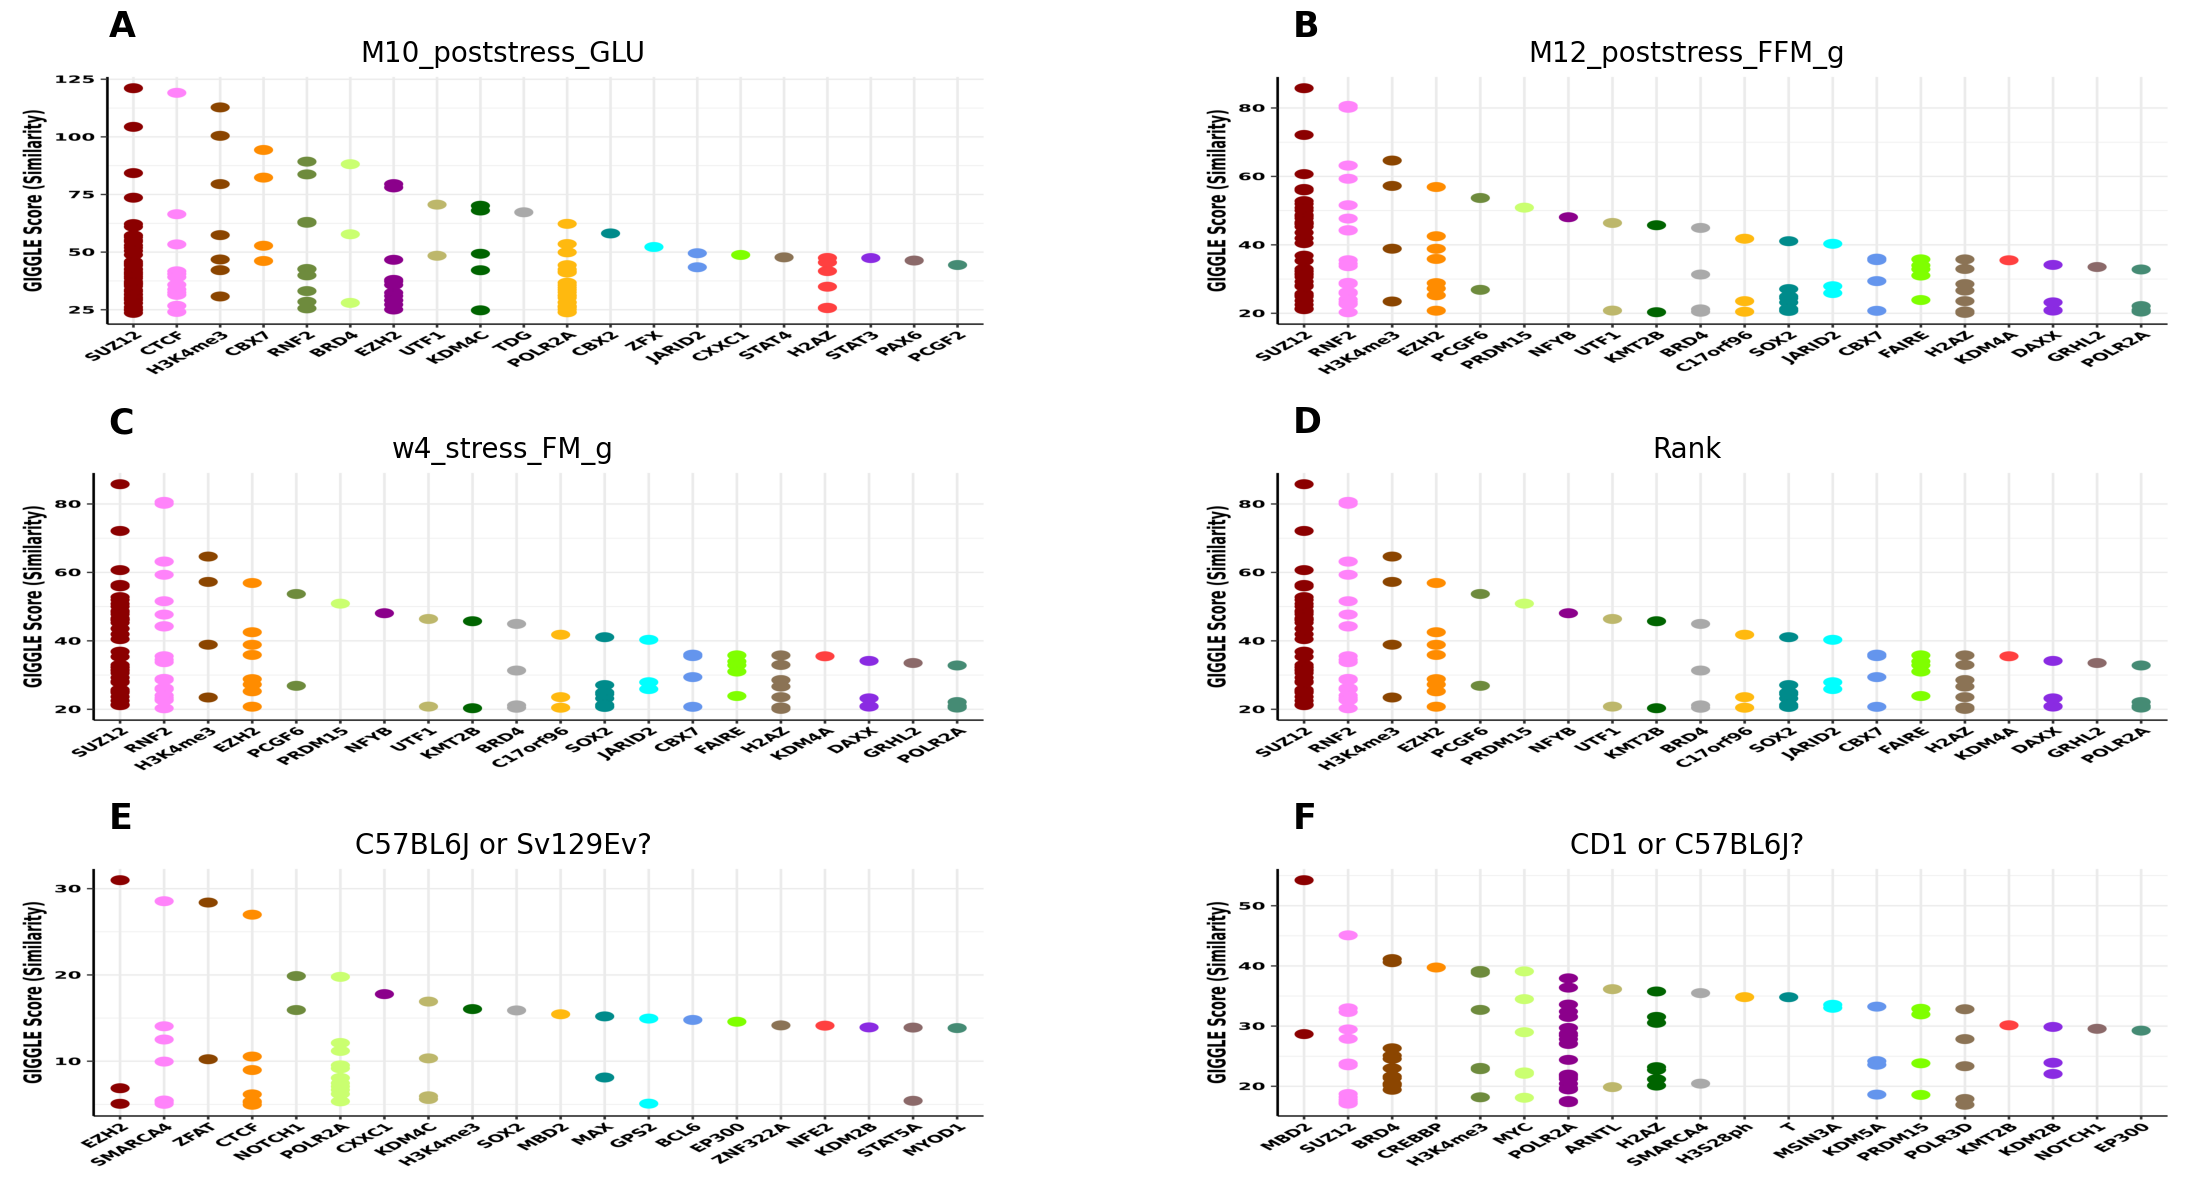

In [65]:
%matplotlib inline

#drop insignificant values
cistrome_df = insig_nan(trait_vals)

#this is trial and error, unfortunately 
fig_w = 2800
fig_h = 3000

#generate cistrome plots by trait for significant probes
get_cistrome(cistrome_df, fig_w, fig_h)